In [1]:
import joblib
import pandas as pd
import numpy as np
import shapiq

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
pipeline = joblib.load(f'../saved-models/{pfs_dir}/best_pipeline{rna_suffix}.joblib')
x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}.csv")
x_test = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}.csv").squeeze()
y_test = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}.csv").squeeze()

x = pd.concat([x_train, x_test])
y = pd.concat([y_train, y_test])


In [3]:
model = pipeline[-1]

x_scaled = pipeline[:-1].transform(x)   # x -> preprocessed 

preprocessed_feature_names = pipeline['preprocess'].get_feature_names_out()
feature_names = [
    n.replace('remainder__', '')
     .replace('m_stage__', '')
     .replace('categorical__', '')
     .replace('sex__', '')
     .replace('age__', '')
     .replace('drug_braf__', '')
    for n in pipeline['preprocess'].get_feature_names_out()
]
n_features = len(feature_names)

## Explain a single sample

In [4]:
explainer = shapiq.Explainer(
    model=model, 
    data=x_scaled,
    max_order=2,
    index='SII',
    random_state=42
)  

iv = explainer.explain(x_scaled[0], budget=256, random_state=42)                         
iv.feature_names = feature_names
print(iv)

InteractionValues(
    index=SII, max_order=2, min_order=0, estimated=True, estimation_budget=256,
    n_players=34, baseline_value=0.43047494239025313,
    Top 10 interactions:
        (5, 9): 0.29869445651094606
        (3, 5): 0.25195281616658166
        (15, 17): 0.24189763869305175
        (10, 32): 0.24022350507252255
        (0, 4): 0.22641300885431698
        (4, 17): 0.21440295501120532
        (13, 22): -0.2089278739980483
        (6, 13): -0.2213227384161694
        (3, 26): -0.23806157088612978
        (13, 21): -0.23976360934414864
)


/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/shapiq/imputer/marginal_imputer.py:109: UserWarning: The sample size is larger than the number of data points in the background set. Reducing the sample size to the number of background samples.
  self.init_background(self.data)


In [5]:
print(iv.get_n_order(2).dict_values)


{(0, 1): -0.0649501639648419, (0, 2): -0.0013576871974473248, (0, 3): -0.0042965624720436866, (0, 4): 0.22641300885431698, (0, 5): -0.19598658963859317, (0, 6): -0.031170772758692147, (0, 7): -0.03251662470272223, (0, 8): -0.03946722301423152, (0, 9): 0.006039263214463359, (0, 10): -0.14102353774395046, (0, 11): 0.03728881667770968, (0, 12): 0.005736244251918397, (0, 13): -0.007236840708267439, (0, 14): 0.09132259082080349, (0, 15): -0.1945823573679948, (0, 16): 0.0398302834088566, (0, 17): -0.10344337805917507, (0, 18): 0.07720060258886631, (0, 19): 0.07143701239116522, (0, 20): -0.050434517741495655, (0, 21): -0.07881617868849909, (0, 22): -0.004605953635178821, (0, 23): 0.10621255056873671, (0, 24): 0.15379699837833044, (0, 25): -0.06294269369178757, (0, 26): 0.018521759813670793, (0, 27): -0.004115640740027118, (0, 28): 0.029416540469627373, (0, 29): 0.11290931350583282, (0, 30): 0.08640755282971001, (0, 31): 0.08326814902769254, (0, 32): -0.06263546527158266, (0, 33): -0.029136020

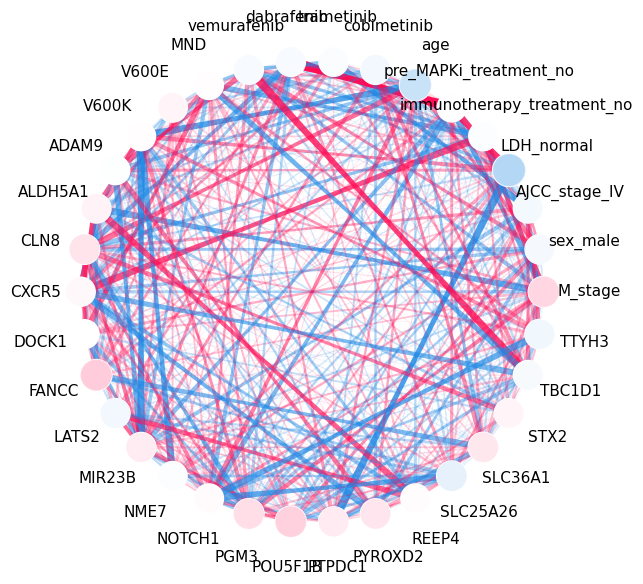

In [6]:
shapiq.network_plot(
    interaction_values=iv,
    feature_names=feature_names,
    show=True
)

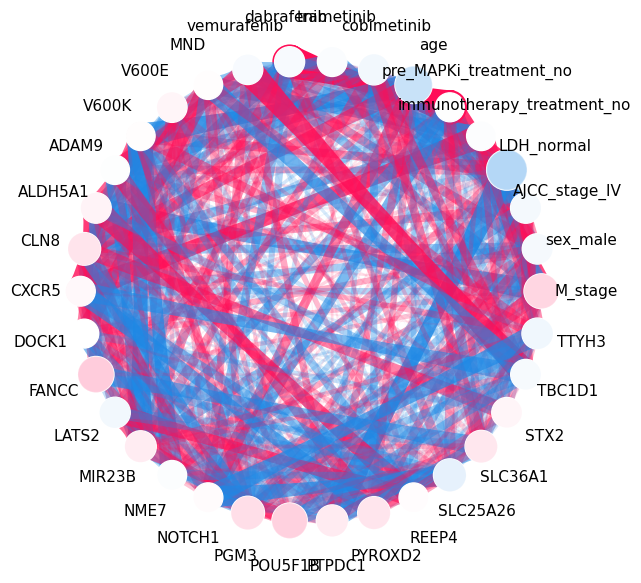

In [7]:
import numpy as np

order2 = iv.get_n_order(2).dict_values
max_int2 = max(abs(v) for v in order2.values())

shapiq.network_plot(
    interaction_values=iv,
    feature_names=feature_names,
    min_max_interactions=(0, max_int2),
    size_factor=3,  # optional, make edges thicker,
    show=True
)


## Global

In [8]:
# parallel explanation of multiple samples
ivs = explainer.explain_X(x_scaled, budget=256, n_jobs=2)
print(f"Computed {len(ivs)} explanations")

Computed 78 explanations


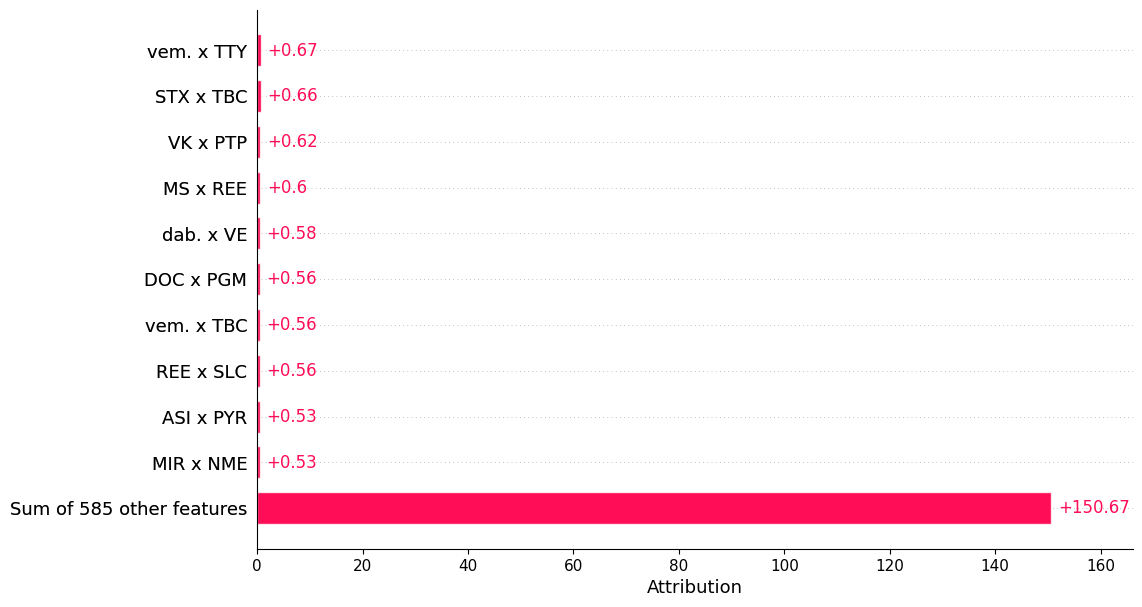

In [9]:
shapiq.plot.bar_plot(ivs, feature_names=feature_names, show=True)

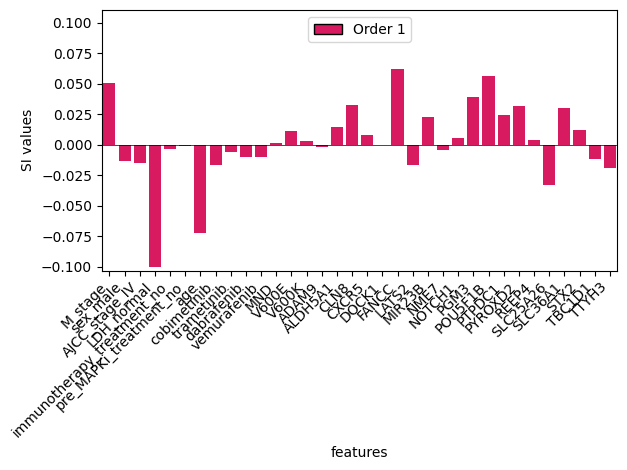

In [10]:
shapiq.stacked_bar_plot(iv.get_n_order(1), feature_names=feature_names, show=True)

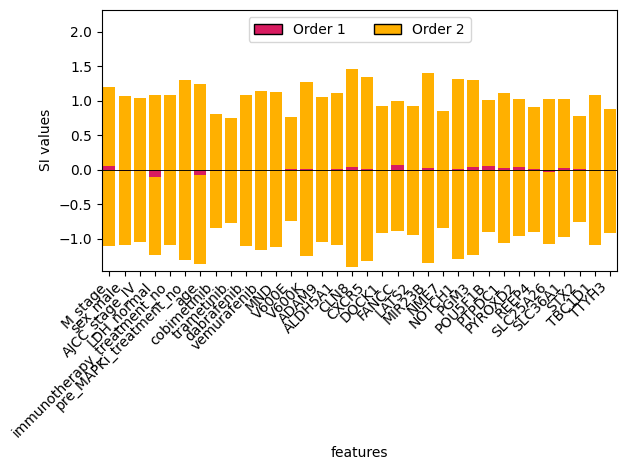

In [11]:
shapiq.stacked_bar_plot(iv, feature_names=feature_names, show=True)

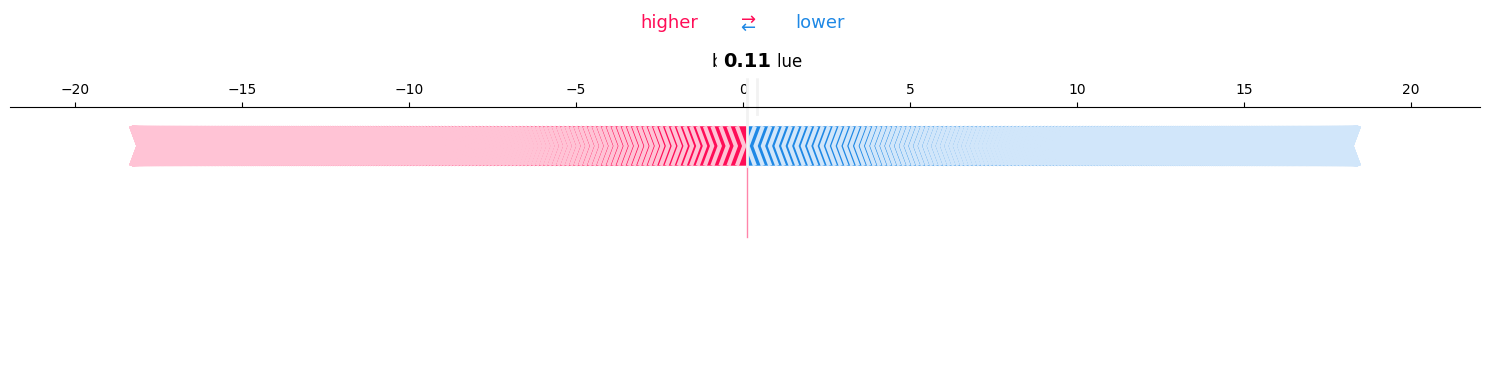

In [12]:
iv.plot_force(feature_names=feature_names, show=True)